# Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math

# Data import

In [2]:
data = pd.read_csv(r'C:\University\Grad!!!!!!!!!\Data collection\Cleaning\Data\Features\emg_cleaned_3_all_features.csv')
data.head()

,filt_WL,filt_AAC,filt_DASDV,filt_IEMG,filt_MAV,filt_MAV1,filt_MAV2,filt_SSI,filt_VAR,filt_TM3,...,env_MTW,env_AR_1,env_AR_2,env_AR_3,env_AR_4,env_CC_1,env_CC_2,env_CC_3,env_CC_4,Output
0,0.0,0.0,0.0,25283.333333,505.666667,379.25,252.833333,1.278494e+07,260917.120181,1.292983e+08,...,13063.134205,1.010880,0.135268,-0.511250,0.275052,-1.010880,0.375671,0.303658,-0.659885,0
1,0.0,0.0,0.0,25283.333333,505.666667,379.25,252.833333,1.278494e+07,260917.120181,1.292983e+08,...,17333.368380,0.786741,0.665717,-0.364734,-0.226162,-0.786741,-0.356237,0.726160,-0.155474,0
2,0.0,0.0,0.0,25283.333333,505.666667,379.25,252.833333,1.278494e+07,260917.120181,1.292983e+08,...,17144.574493,0.997171,0.041110,-0.029669,-0.301653,-0.997171,0.456065,-0.259849,0.479218,0
3,0.0,0.0,0.0,25283.333333,505.666667,379.25,252.833333,1.278494e+07,260917.120181,1.292983e+08,...,16539.320875,0.776699,-0.611650,0.388350,-0.223301,-0.776699,0.913281,-1.019602,1.171956,0
4,0.0,0.0,0.0,25283.333333,505.666667,379.25,252.833333,1.278494e+07,260917.120181,1.292983e+08,...,16521.166667,0.249922,0.249922,0.249922,0.249922,-0.249922,-0.218692,-0.192665,-0.170866,0


# EDA

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 61 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filt_WL       506 non-null    float64
 1   filt_AAC      506 non-null    float64
 2   filt_DASDV    506 non-null    float64
 3   filt_IEMG     506 non-null    float64
 4   filt_MAV      506 non-null    float64
 5   filt_MAV1     506 non-null    float64
 6   filt_MAV2     506 non-null    float64
 7   filt_SSI      506 non-null    float64
 8   filt_VAR      506 non-null    float64
 9   filt_TM3      506 non-null    float64
 10  filt_TM4      506 non-null    float64
 11  filt_TM5      506 non-null    float64
 12  filt_RMS      506 non-null    float64
 13  filt_V_Order  506 non-null    float64
 14  filt_LOG      506 non-null    float64
 15  filt_ZC       506 non-null    int64  
 16  filt_MYOP     506 non-null    float64
 17  filt_WAMP     506 non-null    int64  
 18  filt_SSC      506 non-null    

In [4]:
data.describe()

,filt_WL,filt_AAC,filt_DASDV,filt_IEMG,filt_MAV,filt_MAV1,filt_MAV2,filt_SSI,filt_VAR,filt_TM3,...,env_MTW,env_AR_1,env_AR_2,env_AR_3,env_AR_4,env_CC_1,env_CC_2,env_CC_3,env_CC_4,Output
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,5.060000e+02,506.000000,5.060000e+02,...,5.060000e+02,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,265.643610,5.530550,8.834260,24348.077734,512.472291,384.937985,257.338746,1.249155e+07,269395.970276,1.350857e+08,...,4.373653e+05,0.966332,0.113556,-0.179903,-0.040348,-0.966332,0.440876,-0.181306,0.308535,0.233202
std,552.830166,11.297282,15.412126,3897.983394,10.233512,8.634835,9.833581,2.038791e+06,12828.245666,8.115940e+06,...,1.177000e+06,0.418823,0.309263,0.305033,0.227508,0.418823,0.593957,0.828591,1.252275,0.423288
min,0.000000,0.000000,0.000000,1514.333333,480.100000,360.000000,235.538462,7.644599e+05,235319.816327,1.108300e+08,...,-9.868649e-17,-3.226190,-1.558417,-1.028716,-1.327001,-2.182962,-0.719316,-7.534348,-1.288805,0.000000
25%,0.000000,0.000000,0.000000,25150.000000,507.513333,380.392500,253.391533,1.265045e+07,263231.154762,1.309378e+08,...,8.658060e+03,0.853770,-0.015516,-0.379940,-0.137913,-1.181807,0.000000,-0.407424,-0.221241,0.000000
50%,28.000000,0.596667,2.452614,25516.666667,511.000000,383.250000,255.500000,1.302858e+07,266464.835601,1.334328e+08,...,5.400529e+04,0.983334,0.110794,-0.183167,-0.024978,-0.983334,0.362115,-0.027521,0.045671,0.000000
75%,224.000000,4.876667,9.319317,25616.666667,513.390000,386.856667,259.070067,1.312427e+07,270235.433107,1.358256e+08,...,2.620869e+05,1.181807,0.307556,0.000000,0.054806,-0.853770,0.714515,0.285322,0.443457,0.000000
max,3873.333333,77.466667,100.767553,26908.000000,538.602151,440.125000,377.250000,1.448137e+07,382229.944444,1.562695e+08,...,9.822788e+06,2.182962,1.404868,1.670493,1.500000,3.226190,3.941080,5.255818,16.078968,1.000000


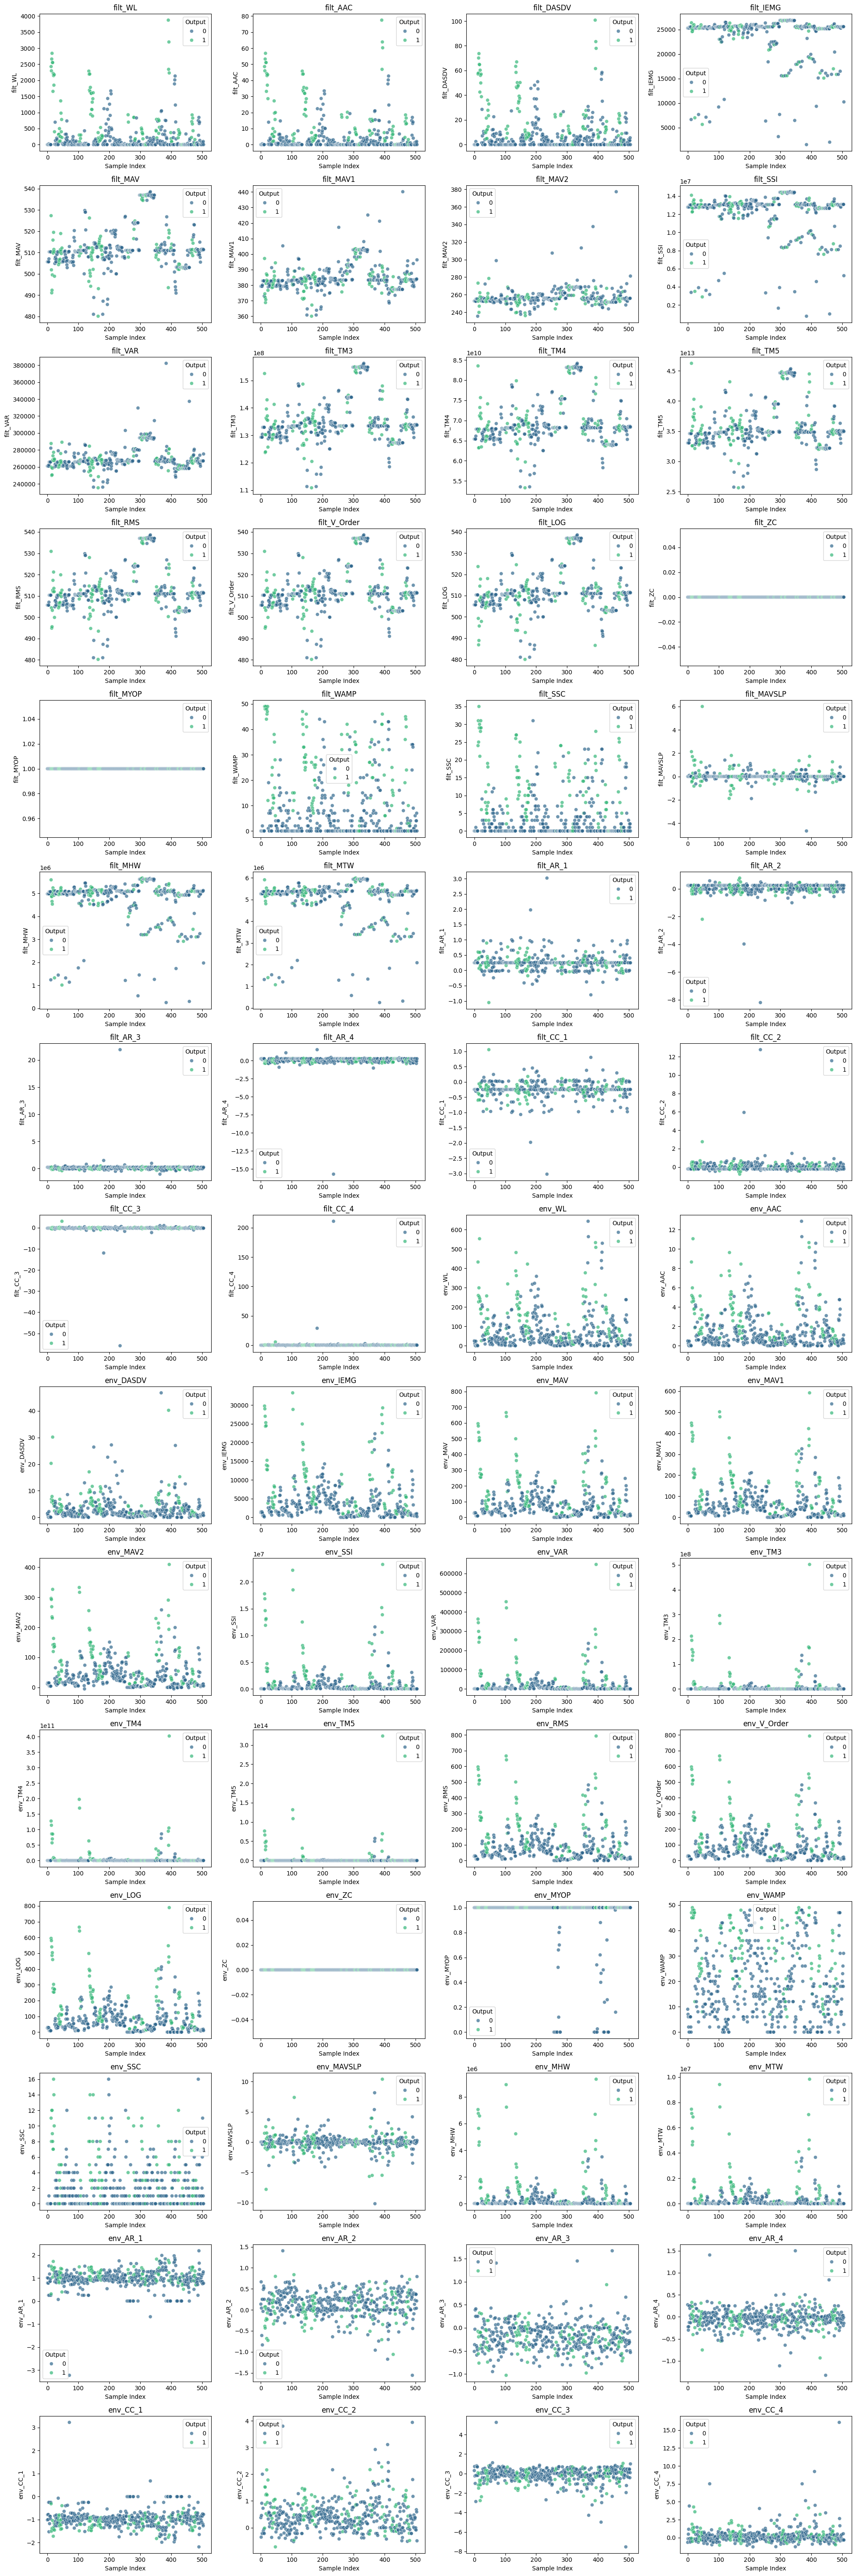

In [5]:
# Get the list of feature columns (excluding 'Output')
features = [col for col in data.columns if col != 'Output']

# Setup a grid of subplots (e.g., 4 columns)
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

# Create the figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

# Iterate through each feature and create a scatter plot
for i, feature in enumerate(features):
    # Scatter plot: x is the index, y is the feature value, color is Output
    sns.scatterplot(
        x=data.index, 
        y=data[feature], 
        hue=data['Output'], 
        ax=axes[i], 
        palette='viridis',
        alpha=0.7 # Slight transparency to see overlapping points
    )
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel("Sample Index")
    axes[i].set_ylabel(feature)

# Remove any unused subplots at the end of the grid
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


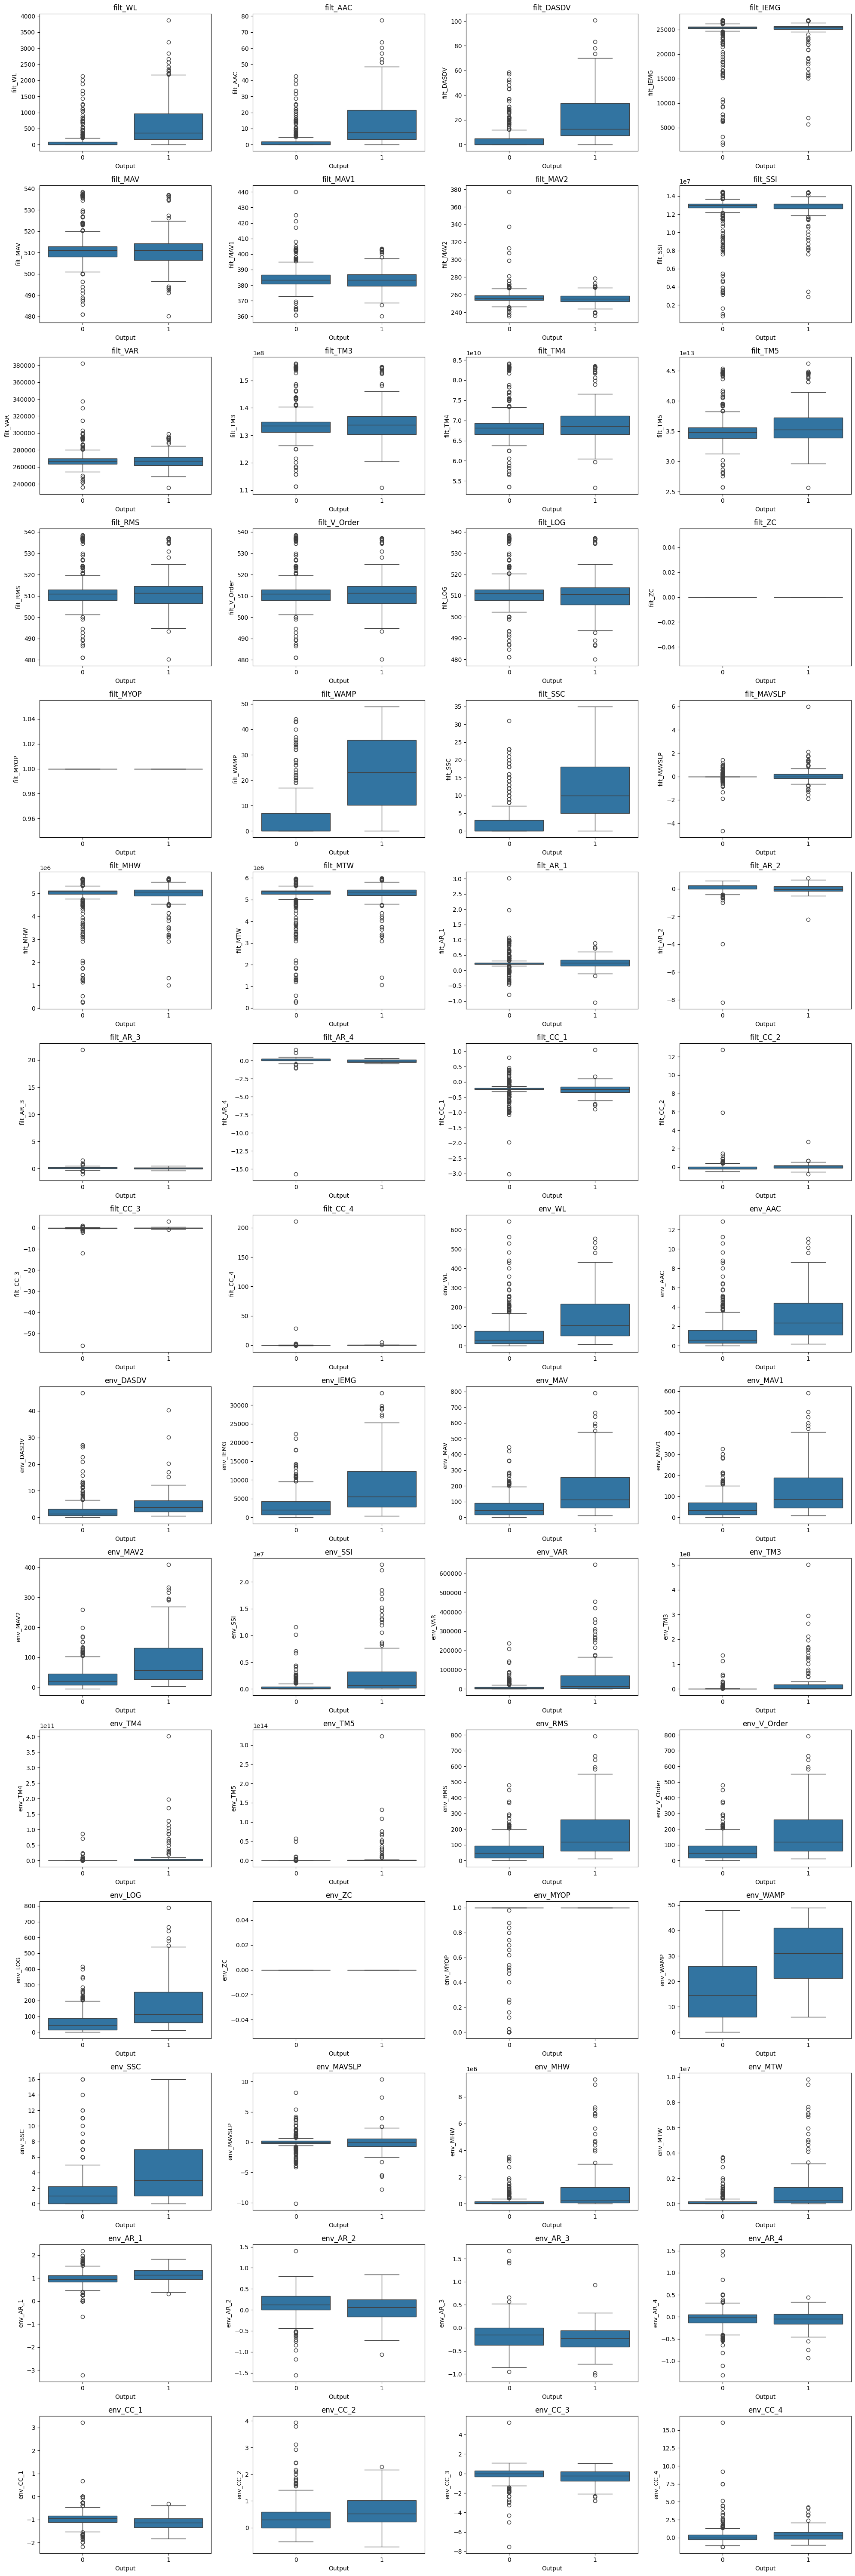

In [6]:
# Get the list of feature columns (excluding 'Output')
features = [col for col in data.columns if col != 'Output']

# Setup a grid of subplots (e.g., 4 columns)
n_cols = 4
n_rows = math.ceil(len(features) / n_cols)

# Create the figure and axes
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 4 * n_rows))
axes = axes.flatten()

# Iterate through each feature and create a box plot
for i, feature in enumerate(features):
    # Box plot: x is Output (the category), y is the feature value
    sns.boxplot(
        x=data['Output'], 
        y=data[feature], 
        ax=axes[i]
    )
    axes[i].set_title(f"{feature}")
    axes[i].set_xlabel("Output")
    axes[i].set_ylabel(feature)

# Remove any unused subplots at the end of the grid
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


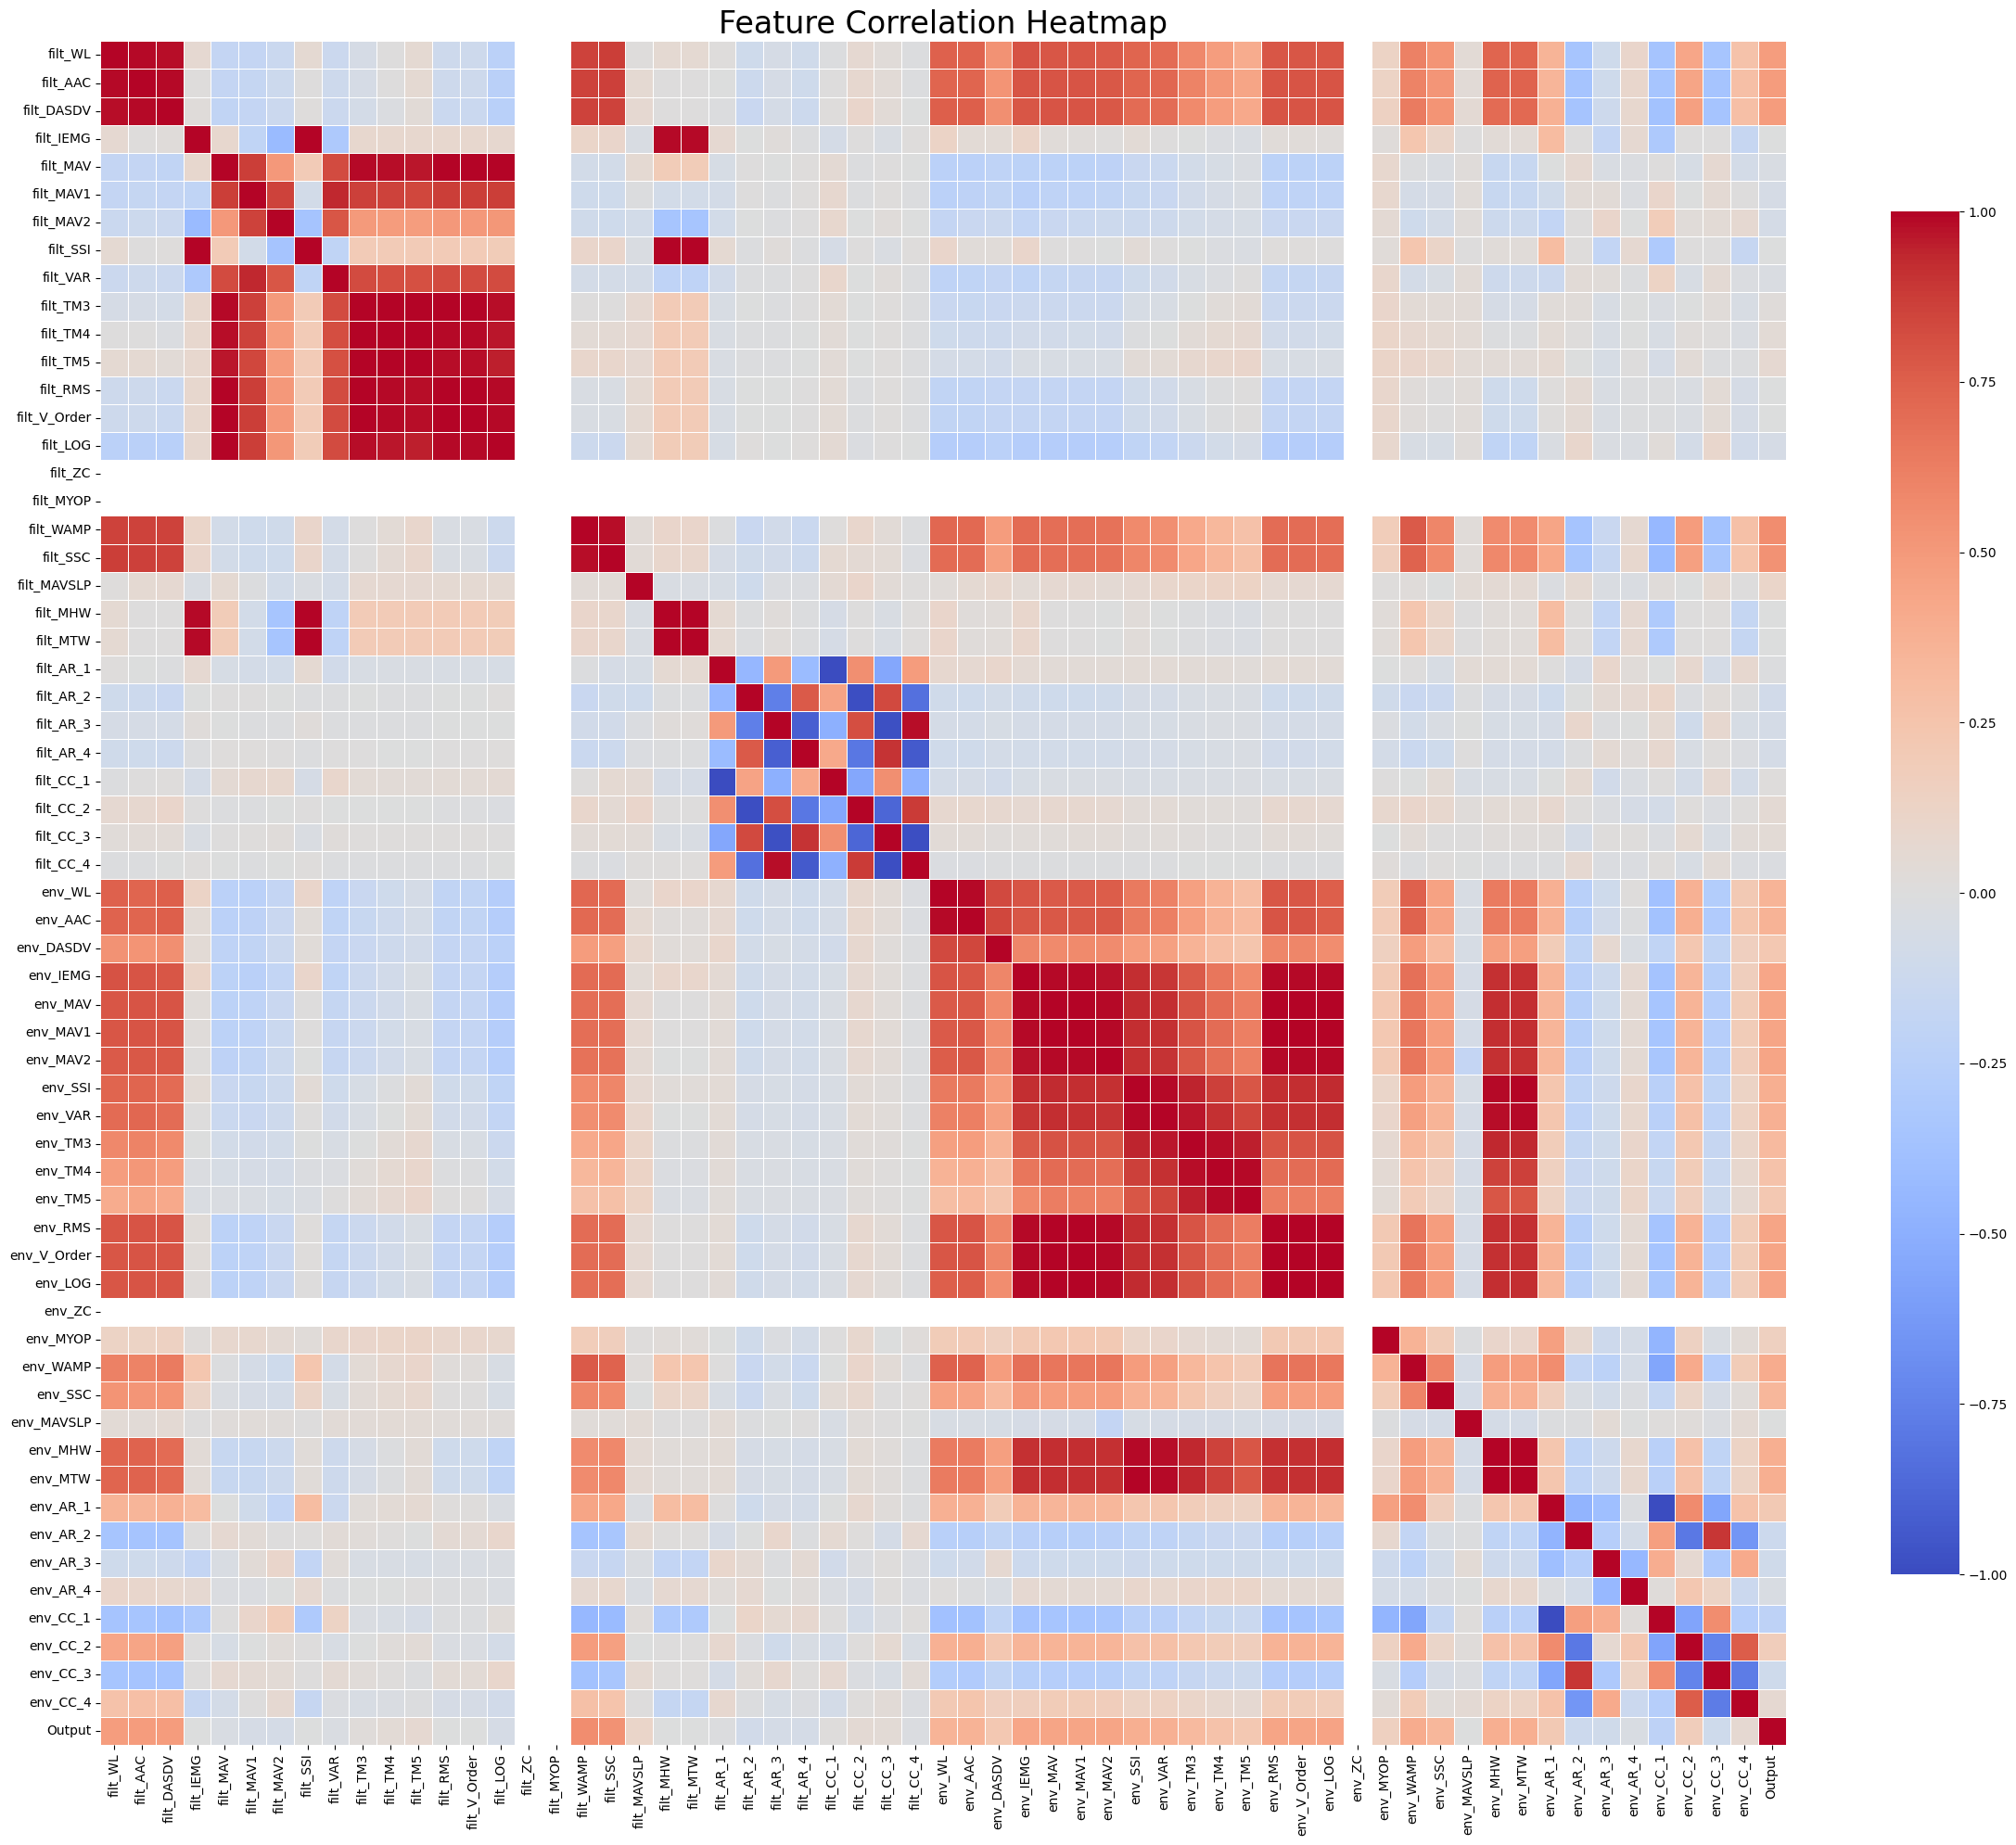

In [7]:
# Calculate the correlation matrix of the dataset
corr_matrix = data.corr()

# Set up the matplotlib figure size (make it large enough for 60+ features)
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(
    corr_matrix, 
    annot=False,            # Set to True if you want to see the exact correlation numbers
    cmap='coolwarm',        # Red for positive correlation, Blue for negative
    vmin=-1, vmax=1,        # Set colorbar scale from -1 to 1
    center=0,               # Center the colormap at 0
    linewidths=0.5,         # Light grid lines between cells
    cbar_kws={"shrink": .8} # Make the colorbar slightly smaller
)

plt.title("Feature Correlation Heatmap", fontsize=24)
plt.tight_layout()
plt.show()


In [8]:
# Check for features that have a standard deviation of 0
zero_var_features = data.columns[data.std() == 0]
print("Features with zero variance (constant values):", list(zero_var_features))

Features with zero variance (constant values): ['filt_ZC', 'filt_MYOP', 'env_ZC']


Zero variance features to avoid when doing feature selection as they're not useful

Some features are highly correlated. Mostly the features that calculate depending on each other and that are a list of values not a single value.

In [9]:
# Set threshold for removing highly correlated features
correlation_threshold = 0.85

# 1. Calculate the correlation matrix (use the absolute values so we catch strong negative correlations too)
corr_matrix = data.corr().abs()

# 2. Select the upper triangle of the correlation matrix
# This prevents us from looking at the same pair twice (e.g., A vs B and B vs A)
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = set()
kept_features = list(data.columns)

print(f"--- Features with Correlation > {correlation_threshold} ---")

# 3. Find index of feature columns with correlation greater than the threshold
for col in upper_tri.columns:
    if col == 'Output': 
        continue # Never drop the target output!
        
    correlated_with = upper_tri.index[upper_tri[col] > correlation_threshold].tolist()
    
    for row in correlated_with:
        if row == 'Output':
            continue
            
        print(f"'{col}' is highly correlated with '{row}' (r = {upper_tri.loc[row, col]:.3f})")
        # Since 'col' comes after 'row' in the upper triangle, we conceptually drop 'col' and keep 'row'
        to_drop.add(col)

# 4. Print the final lists of what to keep vs drop
kept_features = [f for f in data.columns if f not in to_drop]

print("\n--- Summary ---")
print(f"Number of features originally: {len(data.columns)}")
print(f"Number of features dropped: {len(to_drop)}")
print(f"Number of features kept: {len(kept_features)}")

print("\n--- Features Dropped ---")
print(sorted(list(to_drop)))

print("\n--- Features Kept ---")
print(kept_features)

# 5. Create a new dataframe with the dropped features removed
data_filtered = data.drop(columns=to_drop)

--- Features with Correlation > 0.85 ---
'filt_AAC' is highly correlated with 'filt_WL' (r = 0.992)
'filt_DASDV' is highly correlated with 'filt_WL' (r = 0.981)
'filt_DASDV' is highly correlated with 'filt_AAC' (r = 0.989)
'filt_MAV1' is highly correlated with 'filt_MAV' (r = 0.875)
'filt_MAV2' is highly correlated with 'filt_MAV1' (r = 0.857)
'filt_SSI' is highly correlated with 'filt_IEMG' (r = 0.992)
'filt_VAR' is highly correlated with 'filt_MAV1' (r = 0.931)
'filt_TM3' is highly correlated with 'filt_MAV' (r = 0.991)
'filt_TM3' is highly correlated with 'filt_MAV1' (r = 0.866)
'filt_TM4' is highly correlated with 'filt_MAV' (r = 0.981)
'filt_TM4' is highly correlated with 'filt_MAV1' (r = 0.856)
'filt_TM4' is highly correlated with 'filt_TM3' (r = 0.998)
'filt_TM5' is highly correlated with 'filt_MAV' (r = 0.967)
'filt_TM5' is highly correlated with 'filt_TM3' (r = 0.992)
'filt_TM5' is highly correlated with 'filt_TM4' (r = 0.998)
'filt_RMS' is highly correlated with 'filt_MAV' (r

Remaining not highly correlated and zero variance features:

['filt_WL', 'filt_IEMG', 'filt_MAV', 'filt_MAVSLP', 'filt_AR_1', 'filt_AR_2', 'filt_AR_3', 'env_WL', 'env_DASDV', 'env_IEMG', 'env_MYOP', 'env_WAMP', 'env_SSC', 'env_MAVSLP', 'env_AR_1', 'env_AR_2', 'env_AR_3', 'env_AR_4', 'env_CC_2', 'env_CC_4', 'Output']

In [10]:
data['Output'].value_counts()

Output
0    388
1    118
Name: count, dtype: int64

# Neural Network Training

Builds and evaluates a simple neural network using the best hyperparameters
from `hyperparameters.txt`:
- **Hidden Layers:** 2
- **Neurons per layer:** 8
- **Dropout:** 0.41

Three feature sets are evaluated:
1. **Full feature set** (all 60 features)
2. **No highly-correlated features** (~23 features)
3. **No highly-correlated + no zero-variance features** (~20 features)

In [25]:
import os
import numpy as np
import pandas as pd

os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

In [26]:
np.random.seed(13)
tf.random.set_seed(13)

In [27]:
HIDDEN_LAYERS = 2
NEURONS       = 8
DROPOUT       = 0.41

In [28]:
def build_nn(input_dim, hidden_layers=HIDDEN_LAYERS,
             neurons=NEURONS, dropout=DROPOUT):
    """Build a simple binary-classification neural network."""
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation='relu'))
        model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

In [29]:
def train_and_evaluate(X, y, label):
    """Train the NN and return (accuracy, recall, auc_roc) on the test set."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    model = build_nn(X_train.shape[1])
    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
    )
    model.fit(
        X_train, y_train,
        epochs=100, batch_size=32,
        validation_split=0.2,
        callbacks=[es],
        verbose=0,
    )
    y_prob = model.predict(X_test, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    acc     = accuracy_score(y_test, y_pred)
    recall  = recall_score(y_test, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_test, y_prob)

    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Features    : {X.shape[1]}")
    print(f"  Test Acc    : {acc*100:.2f}%")
    print(f"  Recall      : {recall*100:.2f}%")
    print(f"  AUC-ROC     : {auc_roc:.4f}")
    return acc, recall, auc_roc

In [30]:
df_full = pd.read_csv(
    r'C:\University\Grad!!!!!!!!!\Data collection\Cleaning'
    r'\Data\Features\emg_cleaned_3_all_features.csv'
)
print(f"Full dataset loaded: {df_full.shape}")

Full dataset loaded: (506, 61)


In [31]:
X_all = df_full.drop(columns=['Output']).values
y_all = df_full['Output'].values

full_test_accuracy, full_test_recall, full_test_auc_roc = train_and_evaluate(
    X_all, y_all, f"Full Feature Set ({X_all.shape[1]} features)"
)


  Full Feature Set (60 features)
  Features    : 60
  Test Acc    : 76.47%
  Recall      : 0.00%
  AUC-ROC     : 0.4872


In [32]:
correlation_threshold = 0.85
corr_matrix_nn = df_full.corr().abs()
upper_tri_nn   = corr_matrix_nn.where(
    np.triu(np.ones(corr_matrix_nn.shape), k=1).astype(bool)
)
to_drop_nn = set()
for col in upper_tri_nn.columns:
    if col == 'Output':
        continue
    for row in upper_tri_nn.index[upper_tri_nn[col] > correlation_threshold].tolist():
        if row != 'Output':
            to_drop_nn.add(col)

df_no_corr = df_full.drop(columns=to_drop_nn)
X_nc = df_no_corr.drop(columns=['Output']).values
y_nc = df_no_corr['Output'].values

nocorr_test_accuracy, nocorr_test_recall, nocorr_test_auc_roc = train_and_evaluate(
    X_nc, y_nc, f"No Highly-Correlated Features ({X_nc.shape[1]} features)"
)


  No Highly-Correlated Features (23 features)
  Features    : 23
  Test Acc    : 63.73%
  Recall      : 0.00%
  AUC-ROC     : 0.2751


In [33]:
zero_var_cols = [
    col for col in df_full.columns
    if col != 'Output' and df_full[col].var() == 0
]
print(f"Zero-variance features removed: {zero_var_cols}")

df_no_zv = df_full.drop(columns=zero_var_cols)
X_nz = df_no_zv.drop(columns=['Output']).values
y_nz = df_no_zv['Output'].values

nozv_test_accuracy, nozv_test_recall, nozv_test_auc_roc = train_and_evaluate(
    X_nz, y_nz,
    f"No Zero-Variance ({X_nz.shape[1]} features)",
)

Zero-variance features removed: ['filt_ZC', 'filt_MYOP', 'env_ZC']

  No Zero-Variance (57 features)
  Features    : 57
  Test Acc    : 78.43%
  Recall      : 8.33%
  AUC-ROC     : 0.5534


In [34]:
zero_var_cols = [
    col for col in df_no_corr.columns
    if col != 'Output' and df_no_corr[col].var() == 0
]
print(f"Zero-variance features removed: {zero_var_cols}")

df_no_corr_no_zv = df_no_corr.drop(columns=zero_var_cols)
X_ncz = df_no_corr_no_zv.drop(columns=['Output']).values
y_ncz = df_no_corr_no_zv['Output'].values

nocrzv_test_accuracy, nocrzv_test_recall, nocrzv_test_auc_roc = train_and_evaluate(
    X_ncz, y_ncz,
    f"No Highly-Correlated + No Zero-Variance ({X_nz.shape[1]} features)",
)

Zero-variance features removed: ['filt_ZC', 'filt_MYOP', 'env_ZC']

  No Highly-Correlated + No Zero-Variance (57 features)
  Features    : 20
  Test Acc    : 77.45%
  Recall      : 54.17%
  AUC-ROC     : 0.7169


In [35]:
print(f"  {'Feature Set':<44} {'Acc':>6}  {'Recall':>7}  {'AUC-ROC':>8}")
print(f"  {'-'*67}")
print(
    f"  {'Full (' + str(X_all.shape[1]) + ' features)':<44}"
    f" {full_test_accuracy*100:>5.2f}%"
    f"  {full_test_recall*100:>6.2f}%"
    f"  {full_test_auc_roc:>8.4f}"
)
print(
    f"  {'No corr. (' + str(X_nc.shape[1]) + ' features)':<44}"
    f" {nocorr_test_accuracy*100:>5.2f}%"
    f"  {nocorr_test_recall*100:>6.2f}%"
    f"  {nocorr_test_auc_roc:>8.4f}"
)
print(
    f"  {'No zero-var. (' + str(X_nz.shape[1]) + ' features)':<44}"
    f" {nozv_test_accuracy*100:>5.2f}%"
    f"  {nozv_test_recall*100:>6.2f}%"
    f"  {nozv_test_auc_roc:>8.4f}"
)
print(
    f"  {'No corr & zero-var. (' + str(X_ncz.shape[1]) + ' features)':<44}"
    f" {nocrzv_test_accuracy*100:>5.2f}%"
    f"  {nocrzv_test_recall*100:>6.2f}%"
    f"  {nocrzv_test_auc_roc:>8.4f}"
)

  Feature Set                                     Acc   Recall   AUC-ROC
  -------------------------------------------------------------------
  Full (60 features)                           76.47%    0.00%    0.4872
  No corr. (23 features)                       63.73%    0.00%    0.2751
  No zero-var. (57 features)                   78.43%    8.33%    0.5534
  No corr & zero-var. (20 features)            77.45%   54.17%    0.7169


Best performing model uses no highly correlated and no zero-variance features (highest AUC_ROC adn recall with second highest accuracy)

In [37]:
df_no_corr_no_zv.to_csv('features_no_corr_no_zv.csv', index=False)